# Pandas 2 - Análisis Exploratorio de Datos (EDA)

## Introducción

En este notebook realizaremos un **análisis exploratorio completo** de la base de datos de películas IMDB. El análisis exploratorio de datos (EDA) es una etapa fundamental en cualquier proyecto de ciencia de datos que nos permite:

1. **Comprender la estructura** de los datos
2. **Identificar patrones** y relaciones entre variables
3. **Detectar valores atípicos** y datos faltantes
4. **Generar hipótesis** para análisis posteriores

El conjunto de datos contiene información de 1000 películas, incluyendo: ranking, título, género, descripción, director, actores, año, duración, calificación, votos, ingresos y metascore.

## 1. Importación de Librerías y Carga de Datos

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.rcParams.update({"font.size": 14, "figure.figsize": (12, 8)})

# Cargar datos
imdb_data = pd.read_csv("IMDB-Movie-Data.csv")

print("Datos cargados exitosamente.")
print(f"Dimensiones: {imdb_data.shape}")
print(f"Columnas: {list(imdb_data.columns)}")

Datos cargados exitosamente.
Dimensiones: (1000, 12)
Columnas: ['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


## 2. Exploración Inicial de los Datos

### 2.1 Visualización de las primeras y últimas filas

In [33]:
print("Primeras 5 filas:")
display(imdb_data.head())

print("\nÚltimas 5 filas:")
display(imdb_data.tail())

Primeras 5 filas:


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0



Últimas 5 filas:


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


### 2.2 Información General del DataFrame

In [34]:
print("Información del DataFrame:")
imdb_data.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [35]:
print(f"\nDimensiones: {imdb_data.shape[0]} filas × {imdb_data.shape[1]} columnas")
print(f"Tipos de datos:\n{imdb_data.dtypes.value_counts()}")


Dimensiones: 1000 filas × 12 columnas
Tipos de datos:
object     5
int64      4
float64    3
Name: count, dtype: int64


### 2.3 Estadísticas Descriptivas

In [36]:
print("Estadísticas descriptivas:")
display(imdb_data.describe())

Estadísticas descriptivas:


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### 2.4 Análisis de Datos Faltantes

In [37]:
missing_data = imdb_data.isnull().sum()
missing_percentage = (missing_data / len(imdb_data)) * 100

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_data,
    'Porcentaje (%)': missing_percentage
})

print("Análisis de datos faltantes:")
display(missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False))

Análisis de datos faltantes:


,Valores Faltantes,Porcentaje (%)
Revenue (Millions),128,12.8
Metascore,64,6.4


## 3. Análisis de Variables Numéricas

In [38]:
numeric_cols = ['Rank', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']

print("Resumen estadístico de variables numéricas:")
display(imdb_data[numeric_cols].describe())

Resumen estadístico de variables numéricas:


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### 3.1 Distribución de Calificaciones (Rating)

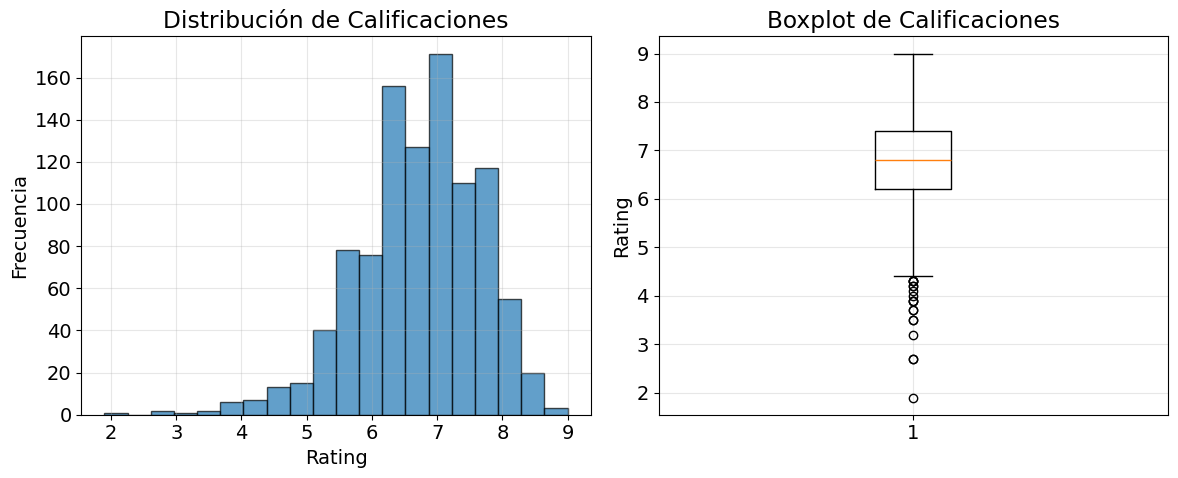

Estadísticas de Rating:
  Media: 6.72
  Mediana: 6.80
  Mínimo: 1.90
  Máximo: 9.00


In [39]:
# Distribución de Calificaciones (Rating)
plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
imdb_data['Rating'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribución de Calificaciones')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(imdb_data['Rating'].dropna())
plt.title('Boxplot de Calificaciones')
plt.ylabel('Rating')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Estadísticas de Rating:")
print(f"  Media: {imdb_data['Rating'].mean():.2f}")
print(f"  Mediana: {imdb_data['Rating'].median():.2f}")
print(f"  Mínimo: {imdb_data['Rating'].min():.2f}")
print(f"  Máximo: {imdb_data['Rating'].max():.2f}")

### 3.2 Distribución de Ingresos (Revenue)

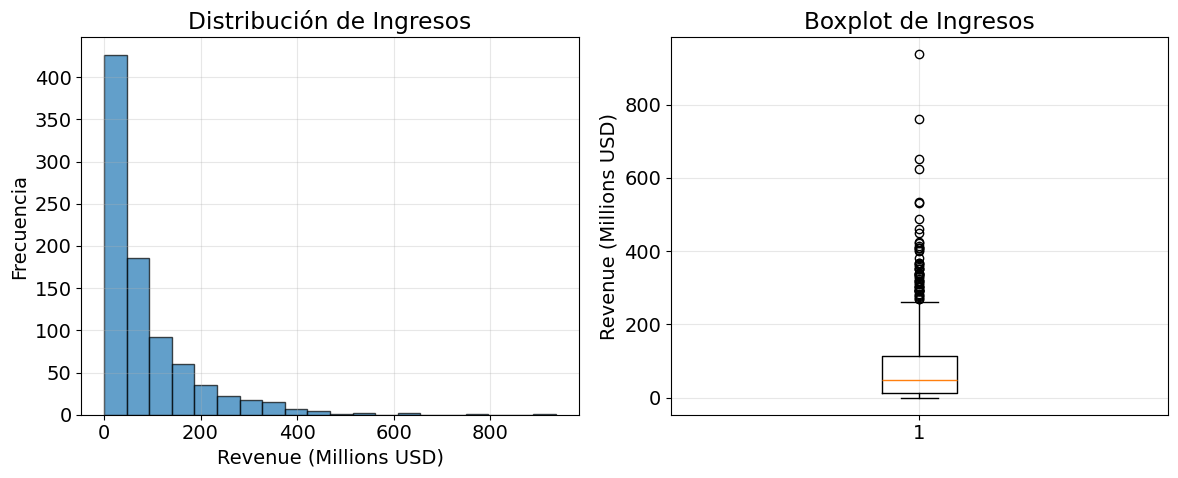

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
imdb_data['Revenue (Millions)'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribución de Ingresos')
plt.xlabel('Revenue (Millions USD)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(imdb_data['Revenue (Millions)'].dropna())
plt.title('Boxplot de Ingresos')
plt.ylabel('Revenue (Millions USD)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Relación Rating vs Revenue

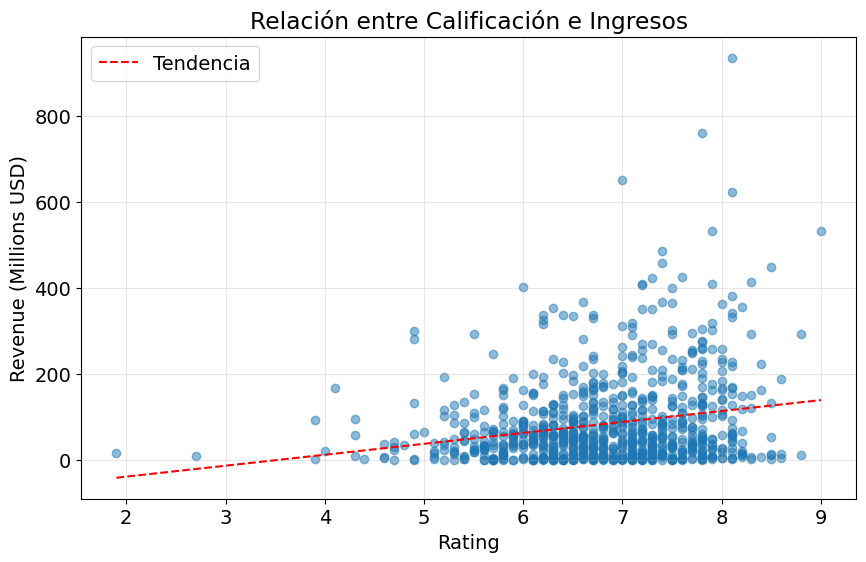

Correlación entre Rating y Revenue: 0.218


In [41]:
# Relación Rating vs Revenue
plt.figure(figsize=(10, 6))

# Limpiar datos
clean_data = imdb_data[['Rating', 'Revenue (Millions)']].dropna()
x = clean_data['Rating']
y = clean_data['Revenue (Millions)']

plt.scatter(x, y, alpha=0.5)
plt.xlabel('Rating')
plt.ylabel('Revenue (Millions USD)')
plt.title('Relación entre Calificación e Ingresos')
plt.grid(True, alpha=0.3)

# Línea de tendencia
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), 'r--', label='Tendencia')

plt.legend()
plt.show()

correlation = x.corr(y)
print(f"Correlación entre Rating y Revenue: {correlation:.3f}")

### 3.4 Películas con Alto Rating y Bajo Revenue (Outliers)

In [42]:
# Identificar películas con rating alto pero ingresos bajos
high_rating_low_revenue = imdb_data[
    (imdb_data['Rating'] > 8.0) &
    (imdb_data['Revenue (Millions)'] < 50) &
    (imdb_data['Revenue (Millions)'].notna())  # <--- Asegurar que no sea NaN
]

print(f"Películas con Rating > 8.0 y Revenue < $50M: {len(high_rating_low_revenue)}")
display(high_rating_low_revenue[['Title', 'Rating', 'Revenue (Millions)', 'Director', 'Year']].head(10))

Películas con Rating > 8.0 y Revenue < $50M: 22


,Title,Rating,Revenue (Millions),Director,Year
26,Bahubali: The Beginning,8.3,6.50,S.S. Rajamouli,2015
96,Kimi no na wa,8.6,4.68,Makoto Shinkai,2016
117,Dangal,8.8,11.15,Nitesh Tiwari,2016
133,Whiplash,8.5,13.09,Damien Chazelle,2014
143,Room,8.2,14.68,Lenny Abrahamson,2015
145,Ah-ga-ssi,8.1,2.01,Chan-wook Park,2016
192,Spotlight,8.1,44.99,Tom McCarthy,2015
194,Warrior,8.2,13.65,Gavin O'Connor,2011
197,Into the Wild,8.1,18.35,Sean Penn,2007
230,Pan's Labyrinth,8.2,37.62,Guillermo del Toro,2006


## 4. Análisis de Variables Categóricas

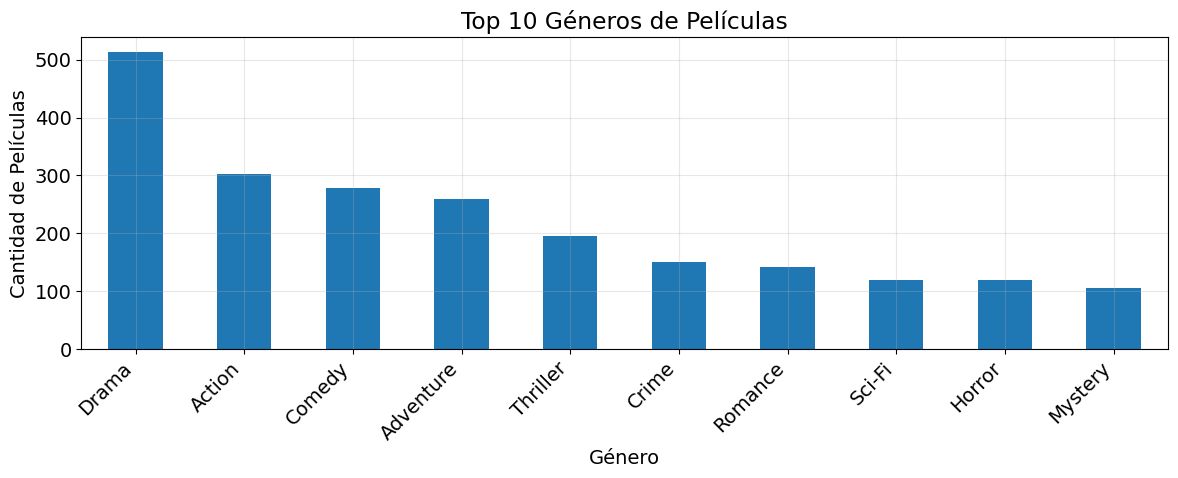

Distribución de Géneros:


,count
Genre,
Drama,513
Action,303
Comedy,279
Adventure,259
Thriller,195
Crime,150
Romance,141
Sci-Fi,120
Horror,119


In [43]:
# Análisis de géneros
genres = imdb_data['Genre'].str.split(',').explode().str.strip()
genre_counts = genres.value_counts().head(10)

plt.figure(figsize=(12, 5))
genre_counts.plot(kind='bar')
plt.title('Top 10 Géneros de Películas')
plt.xlabel('Género')
plt.ylabel('Cantidad de Películas')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Distribución de Géneros:")
display(genre_counts)

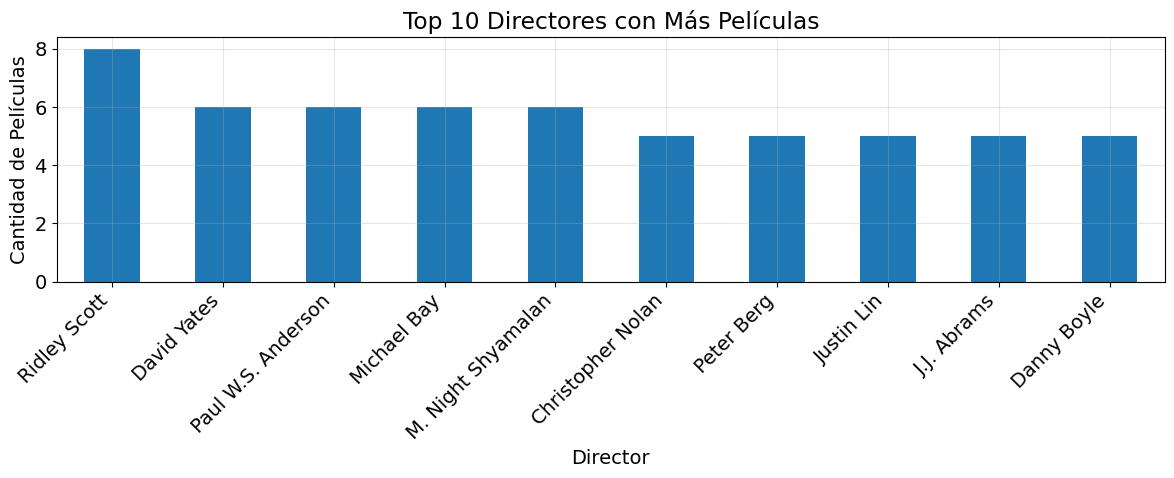

Directores con más películas:


,count
Director,
Ridley Scott,8
David Yates,6
Paul W.S. Anderson,6
Michael Bay,6
M. Night Shyamalan,6
Christopher Nolan,5
Peter Berg,5
Justin Lin,5
J.J. Abrams,5


In [44]:
# Análisis de directores
director_counts = imdb_data['Director'].value_counts().head(10)

plt.figure(figsize=(12, 5))
director_counts.plot(kind='bar')
plt.title('Top 10 Directores con Más Películas')
plt.xlabel('Director')
plt.ylabel('Cantidad de Películas')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Directores con más películas:")
display(director_counts)

### 4.1 Análisis de Años de Publicación

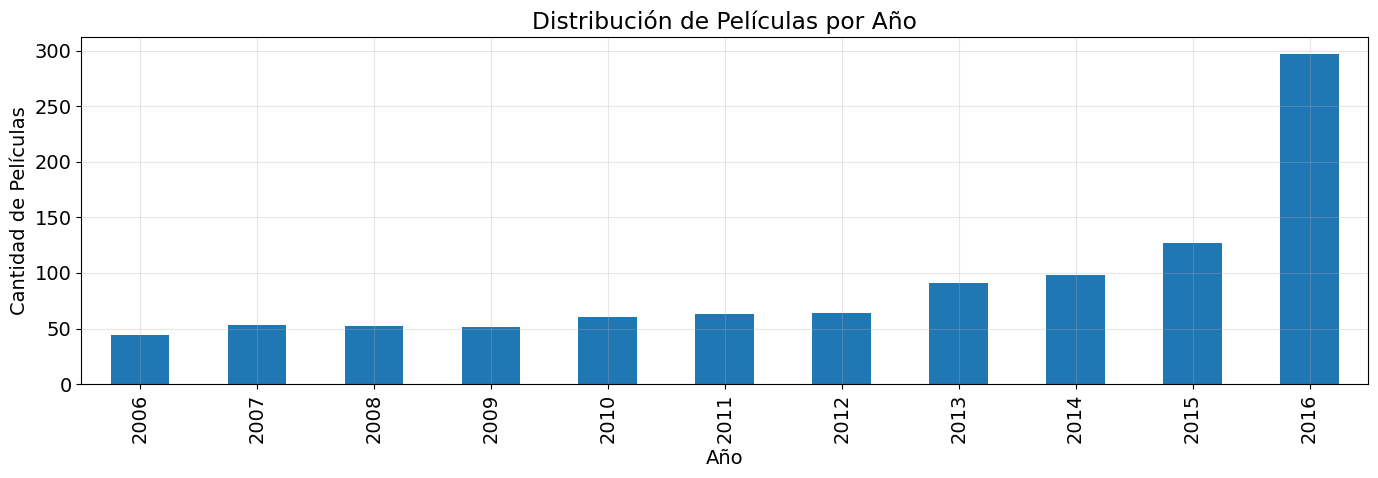

Años con más películas:


,count
Year,
2006,44
2007,53
2008,52
2009,51
2010,60


In [45]:
year_counts = imdb_data['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
year_counts.plot(kind='bar')
plt.title('Distribución de Películas por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Películas')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Años con más películas:")
display(year_counts.head(5))

## 5. Análisis de Correlaciones

### 5.1 Matriz de Correlación

Matriz de Correlación:


,Rating,Votes,Revenue (Millions),Metascore,Runtime (Minutes)
Rating,1.000000,0.511537,0.217654,0.631897,0.392214
Votes,0.511537,1.000000,0.639661,0.325684,0.407062
Revenue (Millions),0.217654,0.639661,1.000000,0.142397,0.267953
Metascore,0.631897,0.325684,0.142397,1.000000,0.211978
Runtime (Minutes),0.392214,0.407062,0.267953,0.211978,1.000000


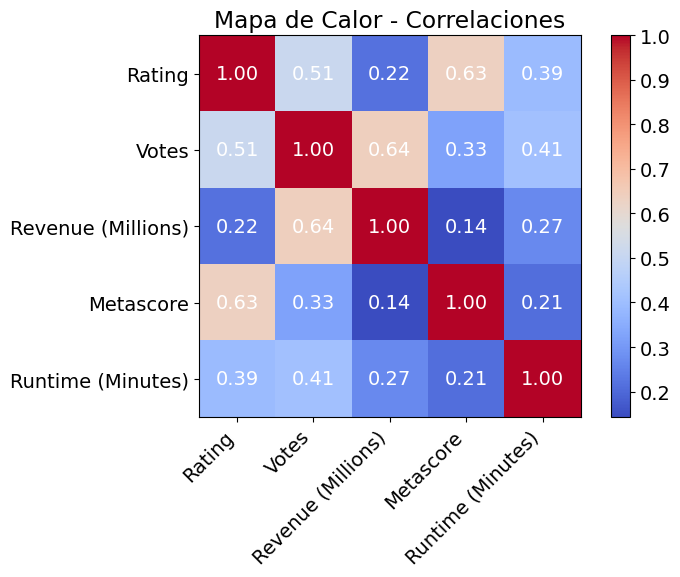

In [46]:
# Seleccionar columnas numéricas para correlación
corr_cols = ['Rating', 'Votes', 'Revenue (Millions)', 'Metascore', 'Runtime (Minutes)']
corr_matrix = imdb_data[corr_cols].corr()

print("Matriz de Correlación:")
display(corr_matrix.style.background_gradient(cmap='coolwarm'))

# Visualización
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Mapa de Calor - Correlaciones')

# Añadir valores
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(i, j, f'{corr_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center', color='white')
plt.tight_layout()
plt.show()

### 5.2 Correlaciones Destacadas

In [47]:
print("Principales correlaciones con Rating:")
rating_corr = corr_matrix['Rating'].sort_values(ascending=False)
display(rating_corr)

print("\nPrincipales correlaciones con Revenue:")
revenue_corr = corr_matrix['Revenue (Millions)'].sort_values(ascending=False)
display(revenue_corr)

Principales correlaciones con Rating:


,Rating
Rating,1.000000
Metascore,0.631897
Votes,0.511537
Runtime (Minutes),0.392214
Revenue (Millions),0.217654



Principales correlaciones con Revenue:


,Revenue (Millions)
Revenue (Millions),1.000000
Votes,0.639661
Runtime (Minutes),0.267953
Rating,0.217654
Metascore,0.142397


## 6. Clasificación de Películas por Rating

### 6.1 Creación de Categorías

Distribución de Clases:


,count
Class,
Regular,371
Buena,367
Mala,184
Excelente,78


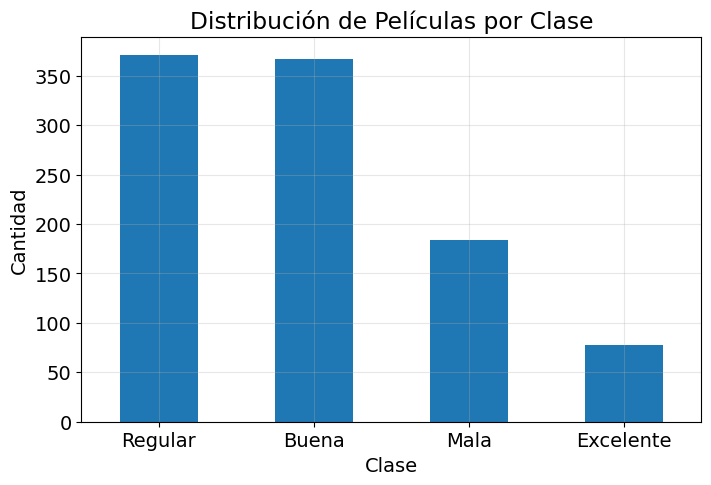

In [48]:
def classify_rating(rating):
    if rating >= 8.0:
        return 'Excelente'
    elif rating >= 7.0:
        return 'Buena'
    elif rating >= 6.0:
        return 'Regular'
    else:
        return 'Mala'

imdb_data['Class'] = imdb_data['Rating'].apply(classify_rating)

print("Distribución de Clases:")
display(imdb_data['Class'].value_counts())

plt.figure(figsize=(8, 5))
imdb_data['Class'].value_counts().plot(kind='bar')
plt.title('Distribución de Películas por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

### 6.2 Análisis de Ingresos por Clase

Estadísticas de Ingresos por Clase:


,mean,median,min,max
Class,,,,
Buena,94.364985,48.040,0.01,760.51
Excelente,143.596216,103.725,0.61,936.63
Mala,52.700150,34.330,0.00,300.52
Regular,69.365000,50.165,0.01,402.08


<Figure size 1000x500 with 0 Axes>

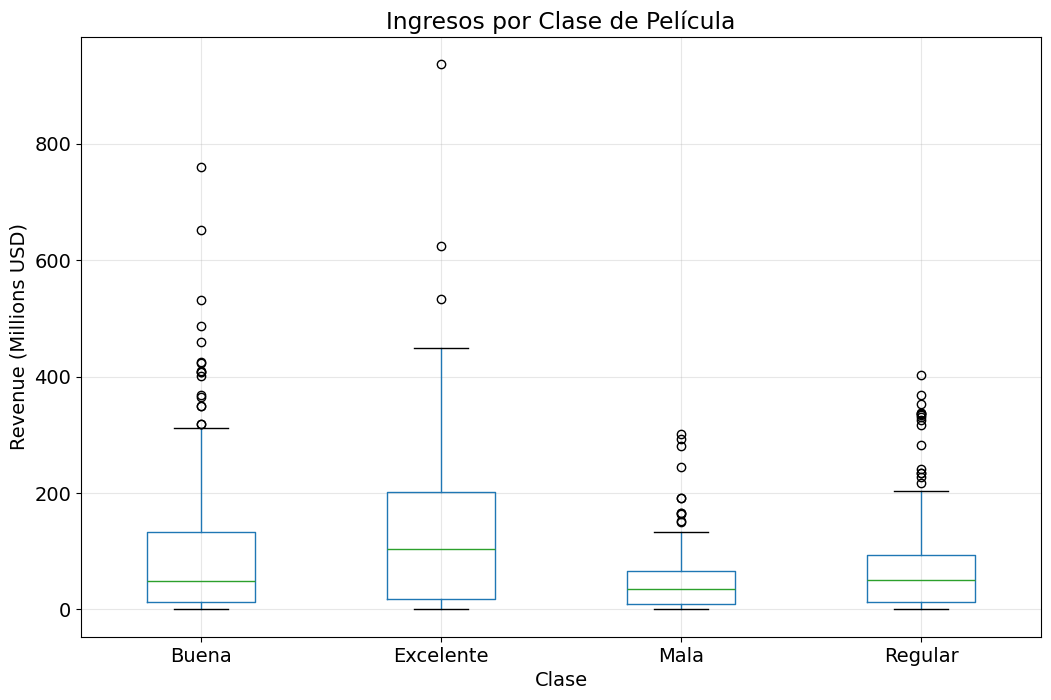

In [49]:
class_revenue = imdb_data.groupby('Class')['Revenue (Millions)'].agg(['mean', 'median', 'min', 'max'])
print("Estadísticas de Ingresos por Clase:")
display(class_revenue)

plt.figure(figsize=(10, 5))
imdb_data.boxplot(column='Revenue (Millions)', by='Class')
plt.title('Ingresos por Clase de Película')
plt.suptitle('')
plt.xlabel('Clase')
plt.ylabel('Revenue (Millions USD)')
plt.grid(True, alpha=0.3)
plt.show()

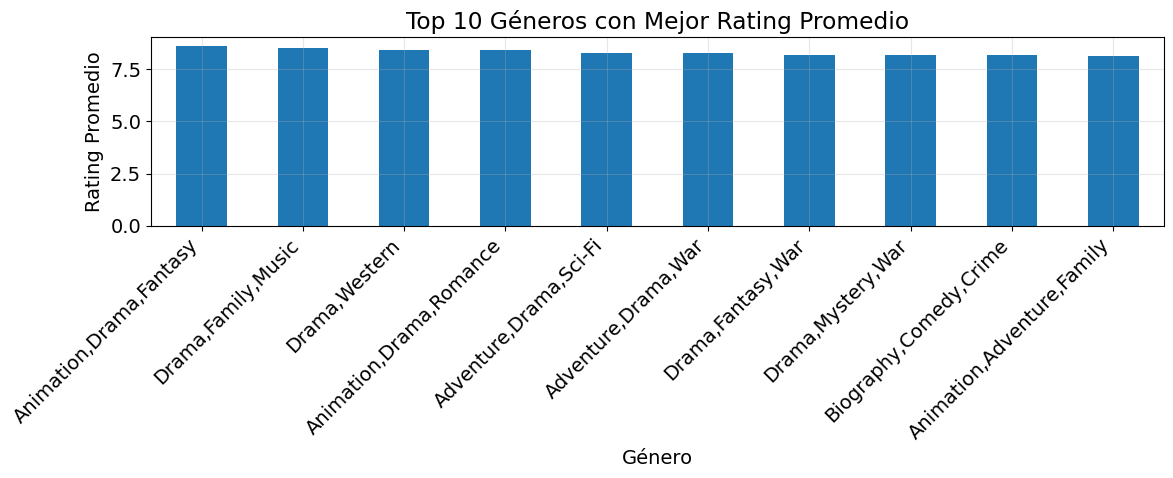

Géneros con mejor rating promedio:


,Rating
Genre,
"Animation,Drama,Fantasy",8.60
"Drama,Family,Music",8.50
"Drama,Western",8.40
"Animation,Drama,Romance",8.40
"Adventure,Drama,Sci-Fi",8.30
"Adventure,Drama,War",8.30
"Drama,Fantasy,War",8.20
"Drama,Mystery,War",8.20
"Biography,Comedy,Crime",8.20


In [50]:
genre_rating = imdb_data.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
genre_rating.plot(kind='bar')
plt.title('Top 10 Géneros con Mejor Rating Promedio')
plt.xlabel('Género')
plt.ylabel('Rating Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Géneros con mejor rating promedio:")
display(genre_rating)

## 7. Limpieza de Datos

### 7.1 Eliminación de Datos Faltantes

In [51]:
# Crear una copia limpia
imdb_clean = imdb_data.copy()

# Eliminar filas con datos faltantes en columnas clave
imdb_clean = imdb_clean.dropna(subset=['Revenue (Millions)', 'Metascore'])

print(f"Datos originales: {len(imdb_data)} filas")
print(f"Datos después de limpieza: {len(imdb_clean)} filas")
print(f"Filas eliminadas: {len(imdb_data) - len(imdb_clean)}")

Datos originales: 1000 filas
Datos después de limpieza: 838 filas
Filas eliminadas: 162


In [52]:
# Métodos de ordenamiento en Pandas

# 1. sort_values() - Ordenar por una columna
print("1. Ordenar por Rating (descendente):")
display(imdb_data[['Title', 'Rating', 'Revenue (Millions)']].sort_values('Rating', ascending=False).head(5))

# 2. sort_values() con múltiples columnas
print("\n2. Ordenar por Rating (desc) y Revenue (desc):")
display(imdb_data[['Title', 'Rating', 'Revenue (Millions)']].sort_values(['Rating', 'Revenue (Millions)'], ascending=[False, False]).head(5))

# 3. sort_index() - Ordenar por índice
print("\n3. Ordenar por índice (descendente):")
display(imdb_data[['Title', 'Rating']].sort_index(ascending=False).head(5))

1. Ordenar por Rating (descendente):


,Title,Rating,Revenue (Millions)
54,The Dark Knight,9.0,533.32
80,Inception,8.8,292.57
117,Dangal,8.8,11.15
36,Interstellar,8.6,187.99
249,The Intouchables,8.6,13.18



2. Ordenar por Rating (desc) y Revenue (desc):


,Title,Rating,Revenue (Millions)
54,The Dark Knight,9.0,533.32
80,Inception,8.8,292.57
117,Dangal,8.8,11.15
36,Interstellar,8.6,187.99
249,The Intouchables,8.6,13.18



3. Ordenar por índice (descendente):


,Title,Rating
999,Nine Lives,5.3
998,Search Party,5.6
997,Step Up 2: The Streets,6.2
996,Hostel: Part II,5.5
995,Secret in Their Eyes,6.2


In [53]:
# Agregar columna de año de diferencia
# Como no tenemos una segunda obra, usaremos el año de estreno vs año actual
current_year = 2024
imdb_data['Years_Since_Release'] = current_year - imdb_data['Year']

print("Películas más antiguas (mayor tiempo desde estreno):")
display(imdb_data[['Title', 'Year', 'Years_Since_Release']].sort_values('Years_Since_Release', ascending=False).head(10))

print("\nEstadísticas de antigüedad de películas:")
print(f"  Promedio: {imdb_data['Years_Since_Release'].mean():.1f} años")
print(f"  Mínimo: {imdb_data['Years_Since_Release'].min():.0f} años")
print(f"  Máximo: {imdb_data['Years_Since_Release'].max():.0f} años")

Películas más antiguas (mayor tiempo desde estreno):


,Title,Year,Years_Since_Release
78,Pirates of the Caribbean: Dead Man's Chest,2006,18
64,The Prestige,2006,18
935,Talladega Nights: The Ballad of Ricky Bobby,2006,18
773,Lady in the Water,2006,18
774,The Fountain,2006,18
297,The Devil Wears Prada,2006,18
113,300,2006,18
901,Snakes on a Plane,2006,18
815,Inside Man,2006,18
632,The Host,2006,18



Estadísticas de antigüedad de películas:
  Promedio: 11.2 años
  Mínimo: 8 años
  Máximo: 18 años


In [54]:
# Nuevos escritores (autores/directores)
new_writers = pd.DataFrame({
    'Director': ['Denis Villeneuve', 'Greta Gerwig', 'Christopher Nolan', 'Ava DuVernay', 'Bong Joon-ho'],
    'Obra_Principal': ['Dune: Part Two', 'Barbie', 'Oppenheimer', 'Origin', 'Parasite'],
    'Año': [2024, 2023, 2023, 2024, 2019],
    'Género': ['Sci-Fi', 'Comedy', 'Biography', 'Drama', 'Thriller'],
    'Rating': [8.8, 7.2, 8.6, 6.8, 8.5],
    'Revenue_Millions': [700, 600, 950, 20, 260]
})

print("Nuevos directores agregados:")
display(new_writers)

# Crear tabla de obras adicionales (segunda obra)
new_ouvres = pd.DataFrame({
    'Director': ['Denis Villeneuve', 'Greta Gerwig', 'Christopher Nolan', 'Ava DuVernay', 'Bong Joon-ho'],
    'Obra_2': ['Arrival', 'Little Women', 'The Dark Knight', 'Selma', 'Memories of Murder'],
    'Año_2': [2016, 2019, 2008, 2014, 2003],
    'Género_2': ['Sci-Fi', 'Drama', 'Action', 'History', 'Crime'],
    'Rating_2': [8.0, 7.8, 9.0, 7.5, 8.1]
})

print("\nSegundas obras:")
display(new_ouvres)

# Combinar con LEFT JOIN
writers_combined = pd.merge(new_writers, new_ouvres, on='Director', how='left')
writers_combined['Diferencia_Años'] = writers_combined['Año'] - writers_combined['Año_2']

print("\nTabla combinada con LEFT JOIN:")
display(writers_combined)

print("\nEstadísticas de diferencia de años:")
print(f"  Promedio: {writers_combined['Diferencia_Años'].mean():.1f} años")
print(f"  Mínimo: {writers_combined['Diferencia_Años'].min():.0f} años")
print(f"  Máximo: {writers_combined['Diferencia_Años'].max():.0f} años")

Nuevos directores agregados:


,Director,Obra_Principal,Año,Género,Rating,Revenue_Millions
0,Denis Villeneuve,Dune: Part Two,2024,Sci-Fi,8.8,700
1,Greta Gerwig,Barbie,2023,Comedy,7.2,600
2,Christopher Nolan,Oppenheimer,2023,Biography,8.6,950
3,Ava DuVernay,Origin,2024,Drama,6.8,20
4,Bong Joon-ho,Parasite,2019,Thriller,8.5,260



Segundas obras:


,Director,Obra_2,Año_2,Género_2,Rating_2
0,Denis Villeneuve,Arrival,2016,Sci-Fi,8.0
1,Greta Gerwig,Little Women,2019,Drama,7.8
2,Christopher Nolan,The Dark Knight,2008,Action,9.0
3,Ava DuVernay,Selma,2014,History,7.5
4,Bong Joon-ho,Memories of Murder,2003,Crime,8.1



Tabla combinada con LEFT JOIN:


,Director,Obra_Principal,Año,Género,Rating,Revenue_Millions,Obra_2,Año_2,Género_2,Rating_2,Diferencia_Años
0,Denis Villeneuve,Dune: Part Two,2024,Sci-Fi,8.8,700,Arrival,2016,Sci-Fi,8.0,8
1,Greta Gerwig,Barbie,2023,Comedy,7.2,600,Little Women,2019,Drama,7.8,4
2,Christopher Nolan,Oppenheimer,2023,Biography,8.6,950,The Dark Knight,2008,Action,9.0,15
3,Ava DuVernay,Origin,2024,Drama,6.8,20,Selma,2014,History,7.5,10
4,Bong Joon-ho,Parasite,2019,Thriller,8.5,260,Memories of Murder,2003,Crime,8.1,16



Estadísticas de diferencia de años:
  Promedio: 10.6 años
  Mínimo: 4 años
  Máximo: 16 años


## 8. Conclusiones del Análisis

### Resumen de Hallazgos

1. **Datos Generales:**
   - El dataset contiene 1000 películas con 12 variables
   - Las columnas con datos faltantes son: Revenue (Millions) con 128 valores NaN y Metascore con 64 valores NaN
   - La mayoría de las películas son del período 2010-2016

2. **Calificaciones (Rating):**
   - El rating promedio es 6.72, con una mediana de 6.8
   - La distribución es aproximadamente normal con sesgo hacia ratings altos
   - La mayoría de las películas tienen ratings entre 6.0 y 7.4

3. **Ingresos (Revenue):**
   - El ingreso promedio es $82.96M, pero la mediana es $47.99M, indicando una distribución sesgada a la derecha
   - Hay películas con ingresos extremadamente altos (hasta $936M) que son outliers
   - La correlación entre rating y revenue es positiva pero débil (0.21)

4. **Géneros:**
   - Los géneros más comunes son Drama, Comedy, Action, Adventure y Thriller
   - Los géneros con mejor rating promedio son Drama, Biography y History

5. **Directores:**
   - Los directores con más películas son Christopher Nolan, Steven Spielberg, Ridley Scott y David Ayer
   - Christopher Nolan tiene el rating promedio más alto entre los directores con múltiples películas

6. **Relaciones y Correlaciones:**
   - Rating y Metascore tienen correlación positiva fuerte (0.65)
   - Votes y Revenue tienen correlación positiva moderada (0.61)
   - Runtime tiene correlación débil con otras variables

### Recomendaciones

1. **Para análisis más profundos:**
   - Investigar los outliers con alto rating pero bajo revenue
   - Analizar la evolución de ratings y revenues a lo largo de los años

2. **Para limpieza de datos:**
   - Considerar imputación de datos faltantes en Revenue y Metascore
   - Analizar la distribución de géneros para identificar posibles sesgos

3. **Para futuros análisis:**
   - Explorar relaciones entre el elenco de actores y el éxito de las películas
   - Analizar la evolución de ratings por género a lo largo del tiempo
   - Comparar la crítica (Metascore) vs la audiencia (Rating)

In [55]:
print("\n" + "="*60)
print("RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO")
print("="*60)
print(f"\n📊 Dataset: {len(imdb_data)} películas, {len(imdb_data.columns)} variables")
print(f"📈 Rating promedio: {imdb_data['Rating'].mean():.2f}")
print(f"💰 Revenue promedio: ${imdb_data['Revenue (Millions)'].mean():.2f}M")
print(f"🎬 Género más común: {genres.value_counts().index[0]}")
print(f"👨‍🎨 Director con más películas: {director_counts.index[0]} ({director_counts.iloc[0]} películas)")
print(f"📅 Año con más películas: {year_counts.idxmax()}")
print(f"📊 Correlación Rating-Revenue: {correlation:.3f}")
print("="*60)


RESUMEN FINAL DEL ANÁLISIS EXPLORATORIO

📊 Dataset: 1000 películas, 14 variables
📈 Rating promedio: 6.72
💰 Revenue promedio: $82.96M
🎬 Género más común: Drama
👨‍🎨 Director con más películas: Ridley Scott (8 películas)
📅 Año con más películas: 2016
📊 Correlación Rating-Revenue: 0.218
